In [ ]:
#DATASET:-https://www.kaggle.com/datasets/mmumairkhattak/e-commerce-orders-dataset-2026-scra?select=ecommerce_orders_dataset.csv

# Order Amount , Product_Category	,
# Product_Subcategory Prediction By **Using Functional API**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [20]:
df=pd.read_csv("ecommerce_orders_dataset.csv")

In [21]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Order_Date,0
Year,0
Month,0
Day,0
Day_Of_Week,0
Quarter,0
Customer_Age,0
Customer_Gender,0


In [22]:
df=df.drop(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week','Product_ID','Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Payment_Method','Traffic_Source', 'Membership_Status', 'Shipping_Method'],axis=1)

In [23]:
df.columns

Index(['Quarter', 'Customer_Age', 'Customer_Gender', 'Country', 'City',
       'Customer_Segment', 'Product_Category', 'Product_Subcategory', 'Brand',
       'Unit_Price', 'Quantity', 'Order_Amount', 'Device_Type',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='object')

In [24]:
x=df.drop(['Order_Amount','Product_Category','Product_Subcategory'],axis=1)

In [25]:
y1=df['Order_Amount']
y2=df['Product_Category']
y3=df['Product_Subcategory']

In [27]:
cat_cols=x.select_dtypes(exclude='number').columns
num_cols=x.select_dtypes(include='number').columns

In [28]:
cat_cols

Index(['Customer_Gender', 'Country', 'City', 'Customer_Segment', 'Brand',
       'Device_Type', 'Warehouse_Region', 'Order_Status', 'Returned', 'Season',
       'Holiday_Season', 'High_Value_Order'],
      dtype='object')

In [30]:
transformer=ColumnTransformer(transformers=[('cat',OneHotEncoder(drop="first",sparse=False,handle_unknown='ignore'),cat_cols)],remainder='passthrough').set_output(transform="pandas")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Quarter                  30000 non-null  int64  
 1   Customer_Age             30000 non-null  int64  
 2   Customer_Gender          30000 non-null  object 
 3   Country                  30000 non-null  object 
 4   City                     30000 non-null  object 
 5   Customer_Segment         30000 non-null  object 
 6   Brand                    30000 non-null  object 
 7   Unit_Price               30000 non-null  float64
 8   Quantity                 30000 non-null  int64  
 9   Device_Type              30000 non-null  object 
 10  Warehouse_Region         30000 non-null  object 
 11  Delivery_Days            30000 non-null  int64  
 12  Order_Status             30000 non-null  object 
 13  Returned                 30000 non-null  object 
 14  Review_Rating         

In [32]:
transformers=ColumnTransformer(transformers=[('cat',OneHotEncoder(drop="first",sparse_output=False,handle_unknown='ignore'),cat_cols)],remainder='passthrough').set_output(transform="pandas")

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
LabelEncoder1=LabelEncoder()
LabelEncoder2=LabelEncoder()


In [36]:
y2=LabelEncoder1.fit_transform(y2)
y3=LabelEncoder2.fit_transform(y3)

In [38]:
x=transformers.fit_transform(x)

In [41]:
len(x.columns)

57

In [42]:
from tensorflow import keras

In [44]:
from keras.layers import Input,Dense
from keras.models import Sequential,Model

In [45]:
input=Input(shape=(57,))

In [47]:
h1=Dense(128,activation='relu')(input)
h2=Dense(64,activation='relu')(h1)
h3=Dense(32,activation='relu')(h2)
h4=Dense(16,activation='relu')(h3)

In [48]:
output1=Dense(1,activation='linear')(h4)
output2=Dense(len(LabelEncoder1.classes_),activation='softmax')(h4)
output3=Dense(len(LabelEncoder2.classes_),activation='softmax')(h4)

In [55]:
model = Model(inputs=input, outputs=[output1, output2, output3])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 57)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      7,424 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         17 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │        136 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │        544 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,985 (74.16 KB)

 Trainable params: 18,985 (74.16 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(optimizer="adam",loss=["mse","sparse_categorical_crossentropy","sparse_categorical_crossentropy"],metrics=["r2_score","accuracy","accuracy"])

In [57]:
model.fit(x,[y1,y2,y3],epochs=100,validation_split=0.2)

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - dense_5_loss: 16685.2578 - dense_5_r2_score: 0.9518 - dense_6_accuracy: 0.4733 - dense_6_loss: 1.4310 - dense_7_accuracy: 0.1093 - dense_7_loss: 3.4288 - loss: 16690.1191 - val_dense_5_loss: 19748.0469 - val_dense_5_r2_score: 0.9400 - val_dense_6_accuracy: 0.4740 - val_dense_6_loss: 1.4285 - val_dense_7_accuracy: 0.1152 - val_dense_7_loss: 3.5608 - val_loss: 19801.8242
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - dense_5_loss: 16558.4805 - dense_5_r2_score: 0.9521 - dense_6_accuracy: 0.4753 - dense_6_loss: 1.4197 - dense_7_accuracy: 0.1166 - dense_7_loss: 3.0788 - loss: 16562.9902 - val_dense_5_loss: 9569.4258 - val_dense_5_r2_score: 0.9709 - val_dense_6_accuracy: 0.4920 - val_dense_6_loss: 1.3655 - val_dense_7_accuracy: 0.1070 - val_dense_7_loss: 3.0377 - val_loss: 9597.8115
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - dense_5_loss: 17401.6094 - dense_5_r2_score: 0.9497 - dense_6_accuracy: 0.4729 - dense_6_loss

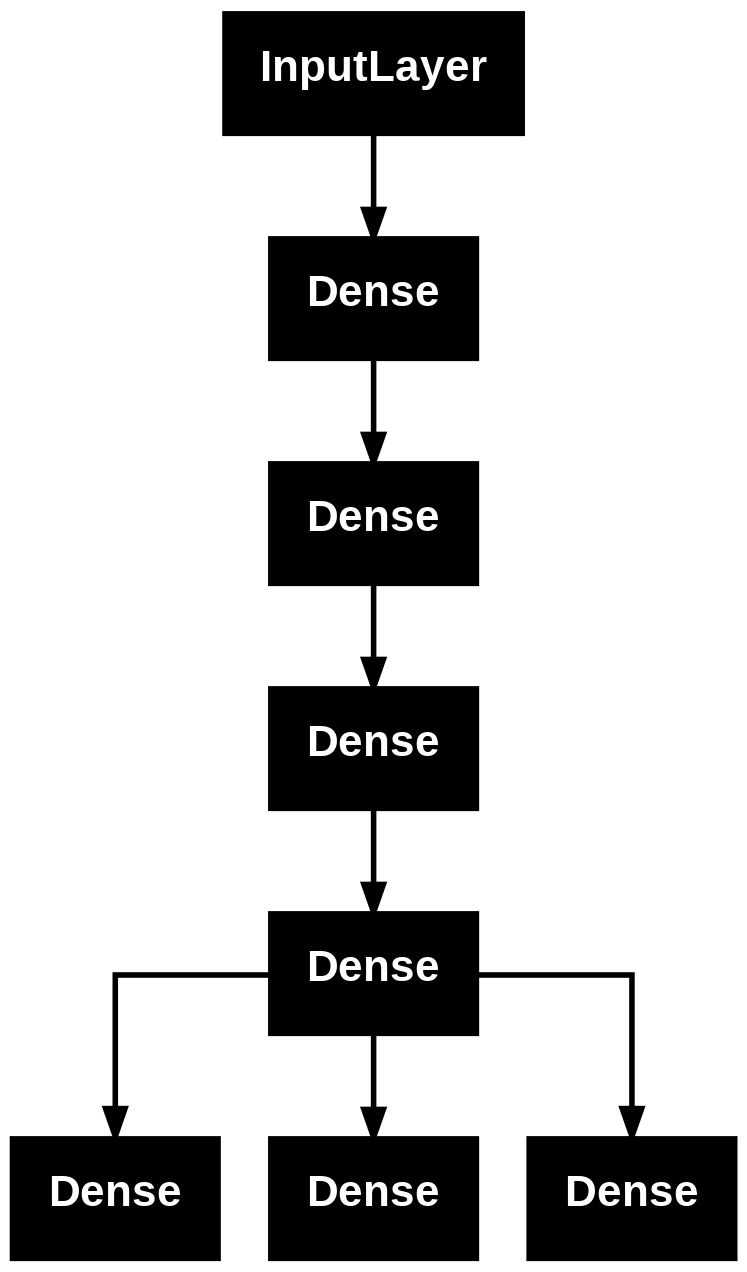

In [58]:
from keras.utils import plot_model

plot_model(model=model)

In [59]:
# for prediction


In [84]:
y_pred=model.predict(x.iloc[20:21])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [85]:
y1_pred=y_pred[0]
y2_pred=y_pred[1]
y3_pred=y_pred[2]

In [86]:
y1_pred

array([[76.41833]], dtype=float32)

In [87]:
LabelEncoder1.inverse_transform(np.argmax(y2_pred,axis=1))

array(['Groceries'], dtype=object)

In [88]:
LabelEncoder2.inverse_transform(np.argmax(y3_pred,axis=1))

array(['Snacks'], dtype=object)

In [83]:
df.iloc[20:21][['Order_Amount','Product_Category','Product_Subcategory']]

,Order_Amount,Product_Category,Product_Subcategory
20,69.51,Books,Comics
